# Tarefa 3 — Pipeline completo de previsão com SARIMAX

Este notebook implementa o pipeline completo:

1. carregar e validar a série temporal semanal;
2. separar treino, validação e teste respeitando a ordem temporal;
3. selecionar o melhor **modelo-base** e o melhor **SARIMA** sem consultar o teste;
4. ajustar o **SARIMAX** com temperatura e feriado;
5. comparar o SARIMAX com os dois benchmarks;
6. devolver todas as previsões na **escala original de vendas**.

O conjunto de teste contém os 20% finais da série e só é usado na avaliação final.

## 1. Bibliotecas e configuração

In [1]:
import os
import warnings
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed, parallel_config
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
plt.style.use("seaborn-v0_8-whitegrid")

RANDOM_STATE = 42
FREQUENCIA = "W-MON"
SAZONALIDADE = 52

## 2. Carregamento, validação e preparação da base

In [2]:
arquivo = Path("dados_aula08_sarimax.xlsx")
if not arquivo.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {arquivo.resolve()}. "
        "Mantenha a planilha na mesma pasta deste notebook."
    )

df = (
    pd.read_excel(arquivo, parse_dates=["data"])
    .sort_values("data")
    .set_index("data")
)

colunas_obrigatorias = {"vendas", "temperatura", "feriado"}
faltantes = colunas_obrigatorias.difference(df.columns)
if faltantes:
    raise ValueError(f"Colunas obrigatórias ausentes: {sorted(faltantes)}")
if df.index.duplicated().any():
    raise ValueError("Existem datas duplicadas.")

# Reindexação explicita a frequência e revela eventuais semanas ausentes.
df = df.asfreq(FREQUENCIA)
if df[list(colunas_obrigatorias)].isna().any().any():
    raise ValueError("Existem semanas ou valores ausentes; trate-os antes da modelagem.")

print(f"Período: {df.index.min().date()} a {df.index.max().date()}")
print(f"Observações: {len(df)} | frequência: {pd.infer_freq(df.index)}")
display(df.head())
display(df.describe().T.round(2))

Período: 2020-01-06 a 2023-12-25
Observações: 208 | frequência: W-MON


,vendas,temperatura,feriado
data,,,
2020-01-06,458.431716,20.993428,1
2020-01-13,689.511394,20.928838,0
2020-01-20,610.337570,23.688534,0
2020-01-27,646.711686,26.592109,0
2020-02-03,644.334682,24.178925,0


,count,mean,std,min,25%,50%,75%,max
vendas,208.0,712.15,114.95,458.43,627.45,705.57,795.89,984.55
temperatura,208.0,19.94,7.52,6.37,12.92,19.61,27.28,33.78
feriado,208.0,0.04,0.19,0.00,0.00,0.00,0.00,1.00


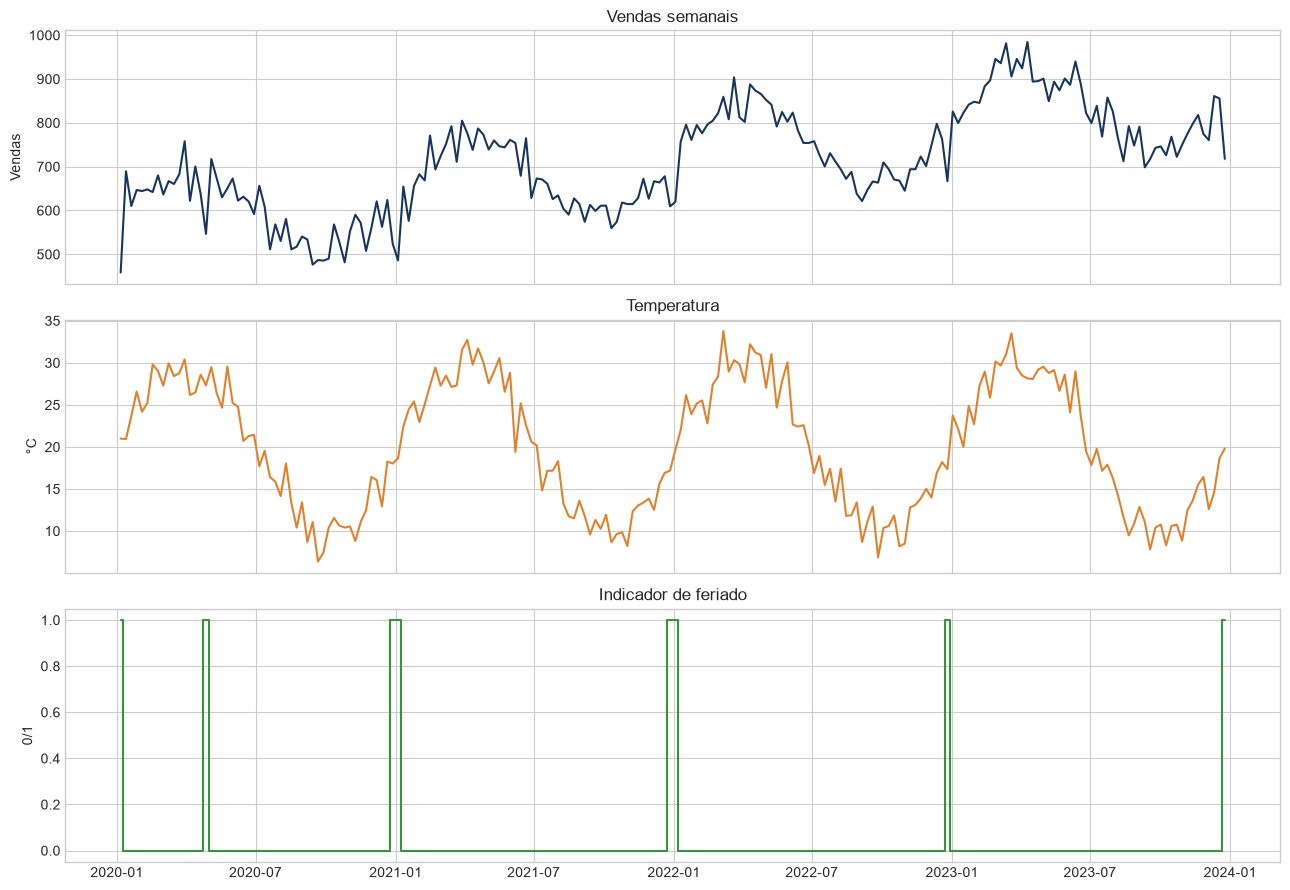

Correlação linear com vendas:


,vendas
vendas,1.000
temperatura,0.558
feriado,-0.233


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(df.index, df["vendas"], color="#17365D")
axes[0].set_title("Vendas semanais")
axes[0].set_ylabel("Vendas")

axes[1].plot(df.index, df["temperatura"], color="#E1812C")
axes[1].set_title("Temperatura")
axes[1].set_ylabel("°C")

axes[2].step(df.index, df["feriado"], where="mid", color="#3A923A")
axes[2].set_title("Indicador de feriado")
axes[2].set_ylabel("0/1")

plt.tight_layout()
plt.show()

print("Correlação linear com vendas:")
display(
    df[["vendas", "temperatura", "feriado"]]
    .corr()[["vendas"]]
    .sort_values("vendas", ascending=False)
    .round(3)
)

## 3. Divisão temporal sem vazamento

- **Teste:** 20% finais da série, preservados para a comparação final.
- **Validação interna:** 20% finais do treino, usados para escolher os modelos.
- Os escalonadores são ajustados apenas na parcela disponível em cada etapa.

Assim, nenhuma informação do futuro entra na seleção ou no treinamento.

Subtreino: 132 observações — até 2022-07-11
Validação:  34 observações — 2022-07-18 a 2023-03-06
Teste:      42 observações — 2023-03-13 a 2023-12-25


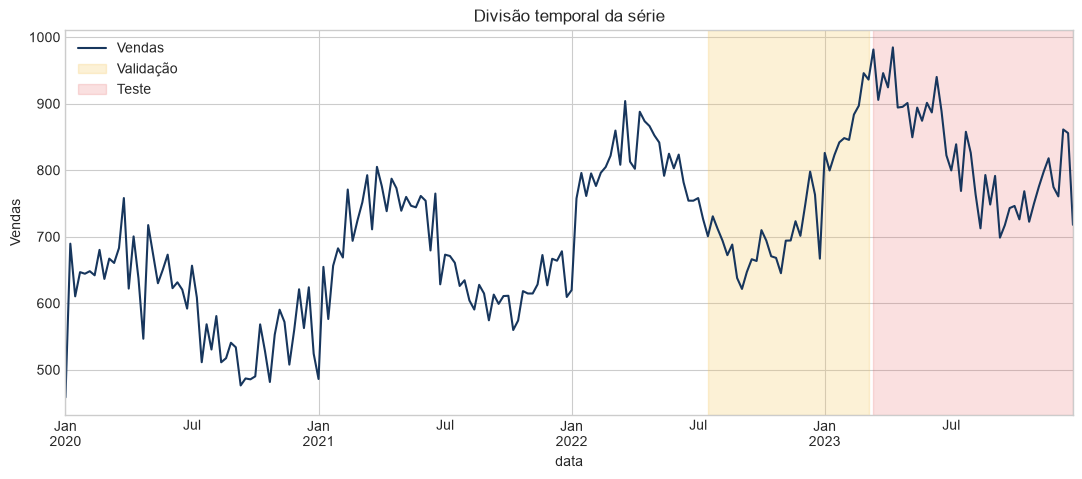

In [4]:
h_teste = int(np.ceil(len(df) * 0.20))
treino = df.iloc[:-h_teste].copy()
teste = df.iloc[-h_teste:].copy()

h_validacao = int(np.ceil(len(treino) * 0.20))
subtreino = treino.iloc[:-h_validacao].copy()
validacao = treino.iloc[-h_validacao:].copy()

print(f"Subtreino: {len(subtreino):3d} observações — até {subtreino.index.max().date()}")
print(f"Validação: {len(validacao):3d} observações — {validacao.index.min().date()} a {validacao.index.max().date()}")
print(f"Teste:     {len(teste):3d} observações — {teste.index.min().date()} a {teste.index.max().date()}")

ax = df["vendas"].plot(figsize=(13, 5), color="#17365D", label="Vendas")
ax.axvspan(validacao.index.min(), validacao.index.max(), color="#F6C85F", alpha=0.25, label="Validação")
ax.axvspan(teste.index.min(), teste.index.max(), color="#E45756", alpha=0.18, label="Teste")
ax.set_title("Divisão temporal da série")
ax.set_ylabel("Vendas")
ax.legend()
plt.show()

## 4. Força de sazonalidade (STL) e justificativa de m

Antes de fixar `SAZONALIDADE = 52`, decompomos a série do **subtreino** com STL e medimos a **força de sazonalidade** $F_s$ (Wang, Smith & Hyndman, 2006):

$$F_s = \max\left(0,\; 1 - \frac{\mathrm{Var}(R_t)}{\mathrm{Var}(S_t + R_t)}\right)$$

em que $S_t$ é o componente sazonal e $R_t$ o resíduo da decomposição STL. Quanto mais próximo de 1, mais forte é a sazonalidade naquele período. Comparamos $m=52$ (ciclo anual, já que a frequência é semanal) com outros períodos candidatos para justificar a escolha usada em todo o notebook (`SAZONALIDADE`).

Força de sazonalidade (Fs) por período candidato, medida no subtreino:


,Fs
Anual (52),0.924
Trimestral (13),0.113
Semestral (26),0.070


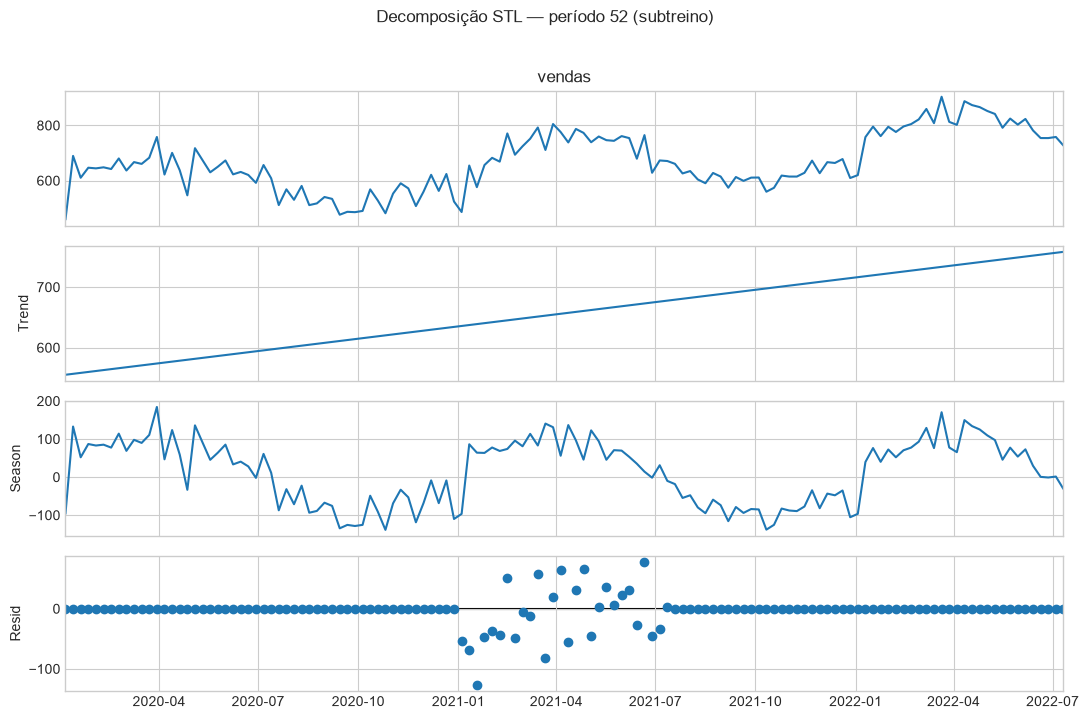

Fs(m=52) = 0.924 — a maior força de sazonalidade entre os períodos testados, o que justifica SAZONALIDADE = 52 (ciclo anual em dados semanais) usada nos modelos SARIMA e SARIMAX deste notebook.


In [5]:
from statsmodels.tsa.seasonal import STL


def forca_sazonalidade(serie, periodo):
    # Fs = 1 - Var(resíduo) / Var(sazonal + resíduo); zero se a sazonalidade não reduz a variância.
    ajuste_stl = STL(serie, period=periodo, robust=True).fit()
    var_residuo = ajuste_stl.resid.var()
    var_sazonal_residuo = (ajuste_stl.seasonal + ajuste_stl.resid).var()
    fs = max(0.0, 1 - var_residuo / var_sazonal_residuo)
    return fs, ajuste_stl


# Períodos candidatos compatíveis com o tamanho do subtreino (mínimo de 2 ciclos completos).
periodos_candidatos = {"Trimestral (13)": 13, "Semestral (26)": 26, "Anual (52)": 52}
forcas_sazonalidade = {}
for nome_periodo, periodo in periodos_candidatos.items():
    fs, _ = forca_sazonalidade(subtreino["vendas"], periodo)
    forcas_sazonalidade[nome_periodo] = fs

ranking_fs = (
    pd.Series(forcas_sazonalidade, name="Fs")
    .sort_values(ascending=False)
    .to_frame()
)
print("Força de sazonalidade (Fs) por período candidato, medida no subtreino:")
display(ranking_fs.round(3))

_, stl_anual = forca_sazonalidade(subtreino["vendas"], SAZONALIDADE)
fig = stl_anual.plot()
fig.set_size_inches(11, 7)
plt.suptitle(f"Decomposição STL — período {SAZONALIDADE} (subtreino)", y=1.02)
plt.tight_layout()
plt.show()

fs_52 = forcas_sazonalidade["Anual (52)"]
print(
    f"Fs(m={SAZONALIDADE}) = {fs_52:.3f} — a maior força de sazonalidade entre os períodos "
    "testados, o que justifica SAZONALIDADE = 52 (ciclo anual em dados semanais) usada nos "
    "modelos SARIMA e SARIMAX deste notebook."
)


## 5. Funções auxiliares e modelos-base

In [6]:
def previsao_base(serie, horizonte, metodo, sazonalidade=SAZONALIDADE):
    # Previsão multi-step baseada somente no histórico recebido.
    y = np.asarray(serie, dtype=float)

    if metodo == "Média histórica":
        return np.repeat(y.mean(), horizonte)
    if metodo == "Naïve":
        return np.repeat(y[-1], horizonte)
    if metodo == "Drift":
        passo = (y[-1] - y[0]) / (len(y) - 1)
        return y[-1] + passo * np.arange(1, horizonte + 1)
    if metodo == "Naïve sazonal":
        if len(y) < sazonalidade:
            raise ValueError("Histórico insuficiente para o naïve sazonal.")
        return np.resize(y[-sazonalidade:], horizonte)

    raise ValueError(f"Método desconhecido: {metodo}")


def calcular_metricas(real, previsto):
    real = np.asarray(real, dtype=float)
    previsto = np.asarray(previsto, dtype=float)
    return {
        "MAE": mean_absolute_error(real, previsto),
        "RMSE": np.sqrt(mean_squared_error(real, previsto)),
        "MAPE (%)": np.mean(np.abs((real - previsto) / real)) * 100,
    }


def voltar_escala(scaler, valores):
    # Inverte a padronização e devolve um vetor na unidade de vendas.
    return scaler.inverse_transform(np.asarray(valores).reshape(-1, 1)).ravel()

In [7]:
metodos_base = ["Média histórica", "Naïve", "Drift", "Naïve sazonal"]

avaliacao_base = []
for metodo in metodos_base:
    pred = previsao_base(subtreino["vendas"], h_validacao, metodo)
    avaliacao_base.append({"Modelo-base": metodo, **calcular_metricas(validacao["vendas"], pred)})

ranking_base = pd.DataFrame(avaliacao_base).sort_values("MAE").reset_index(drop=True)
melhor_base = ranking_base.loc[0, "Modelo-base"]

print("Seleção do modelo-base na validação interna (escala original):")
display(ranking_base.round(2))
print("Melhor modelo-base:", melhor_base)

Seleção do modelo-base na validação interna (escala original):


,Modelo-base,MAE,RMSE,MAPE (%)
0,Drift,66.84,76.28,9.13
1,Naïve,72.83,90.61,9.40
2,Naïve sazonal,75.76,83.87,10.12
3,Média histórica,82.08,116.07,10.01


Melhor modelo-base: Drift


## 6. Seleção do benchmark SARIMA

A busca abaixo é exaustiva **dentro dos limites definidos para cada hiperparâmetro**: ela monta o produto cartesiano de p, d, q, P, D e Q, sempre com período anual de 52 semanas. Assim, a seleção não depende de uma lista manual de candidatos. O vencedor é o modelo convergido com menor **MAE na validação**; o conjunto de teste continua completamente isolado, e o BIC é usado apenas como desempate.

As combinações são ajustadas em **processos paralelos usando todos os núcleos lógicos disponíveis**. Cada processo recebe uma thread numérica interna, evitando a multiplicação excessiva de processos por threads.

> Não existe uma busca por “todas as ordens” sem definir limites, pois as ordens podem crescer indefinidamente. A grade padrão abaixo avalia 144 combinações e pode ser ampliada alterando apenas grade_sarima.

In [8]:
grade_sarima = {
    "p": range(0, 3),
    "d": [0, 1],
    "q": range(0, 3),
    "P": range(0, 2),
    "D": [0, 1],
    "Q": range(0, 2),
}

# -1 instrui o joblib a usar todos os processadores disponíveis.
N_JOBS = -1
NUCLEOS_LOGICOS = os.cpu_count() or 1
MAXITER_GRID = 100

# Produto cartesiano: toda combinação dentro dos limites é testada.
combinacoes_sarima = list(
    product(*(grade_sarima[chave] for chave in ["p", "d", "q", "P", "D", "Q"]))
)
print(f"Total de combinações SARIMA: {len(combinacoes_sarima)}")
print(f"Execução paralela: até {NUCLEOS_LOGICOS} processos (todos os núcleos lógicos)")

# y é padronizado com estatísticas exclusivas do subtreino.
scaler_y_interno = StandardScaler()
y_sub_z = scaler_y_interno.fit_transform(subtreino[["vendas"]]).ravel()
y_val = validacao["vendas"].to_numpy()


def avaliar_combinacao_sarima(combinacao):
    p, d, q, P, D, Q = combinacao
    ordem = (p, d, q)
    ordem_sazonal = (P, D, Q, SAZONALIDADE)
    resultado = {
        "order": ordem,
        "seasonal_order": ordem_sazonal,
        "MAE_validação": np.nan,
        "BIC": np.nan,
        "Convergiu": False,
        "Status": "falha",
        "Erro": None,
    }

    try:
        ajuste = SARIMAX(
            y_sub_z,
            order=ordem,
            seasonal_order=ordem_sazonal,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False, maxiter=MAXITER_GRID)

        pred_val_z = np.asarray(ajuste.get_forecast(h_validacao).predicted_mean)
        pred_val = voltar_escala(scaler_y_interno, pred_val_z)
        convergiu = bool(ajuste.mle_retvals.get("converged", True))
        mae_validacao = mean_absolute_error(y_val, pred_val)

        resultado.update(
            {
                "MAE_validação": mae_validacao,
                "BIC": ajuste.bic,
                "Convergiu": convergiu,
                "Status": "ok" if convergiu else "não convergiu",
            }
        )
    except Exception as erro:
        resultado["Erro"] = f"{type(erro).__name__}: {erro}"

    return resultado


# loky cria processos separados. Limitar cada processo a uma thread evita
# oversubscription de bibliotecas numéricas como BLAS/OpenMP.
with parallel_config(
    backend="loky",
    n_jobs=N_JOBS,
    inner_max_num_threads=1,
):
    avaliacao_sarima = Parallel(
        verbose=10,
        pre_dispatch="2*n_jobs",
        batch_size=1,
    )(
        delayed(avaliar_combinacao_sarima)(combinacao)
        for combinacao in combinacoes_sarima
    )

# Mantém todas as tentativas para auditoria, inclusive falhas.
resultado_grid_sarima = pd.DataFrame(avaliacao_sarima)
elegiveis = resultado_grid_sarima[
    resultado_grid_sarima["Convergiu"]
    & np.isfinite(resultado_grid_sarima["MAE_validação"])
].copy()

ranking_sarima = (
    elegiveis.sort_values(["MAE_validação", "BIC"], na_position="last")
    .reset_index(drop=True)
)
if ranking_sarima.empty:
    raise RuntimeError("Nenhuma combinação SARIMA convergiu com MAE finito.")

melhor_ordem = tuple(ranking_sarima.loc[0, "order"])
melhor_ordem_sazonal = tuple(ranking_sarima.loc[0, "seasonal_order"])

print("Resumo da busca:")
display(
    resultado_grid_sarima["Status"]
    .value_counts()
    .rename_axis("Status")
    .to_frame("Quantidade")
)
print("20 melhores SARIMA na validação interna:")
display(ranking_sarima.drop(columns="Erro").head(20).round(2))
print("Melhor SARIMA:", melhor_ordem, "x", melhor_ordem_sazonal)

Total de combinações SARIMA: 144
Execução paralela: até 12 processos (todos os núcleos lógicos)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   14.1s


[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   15.8s


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   18.8s


...

[Parallel(n_jobs=-1)]: Done 144 out of 144 | elapsed:  2.7min finished


,Quantidade
Status,
ok,142
não convergiu,2


20 melhores SARIMA na validação interna:


,order,seasonal_order,MAE_validação,BIC,Convergiu,Status
0,"(1, 0, 2)","(0, 1, 1, 52)",22.34,37.72,True,ok
1,"(2, 0, 2)","(0, 1, 1, 52)",22.58,40.87,True,ok
2,"(0, 1, 2)","(1, 1, 0, 52)",23.85,43.15,True,ok
3,"(1, 1, 1)","(0, 1, 1, 52)",23.86,34.80,True,ok
4,"(0, 1, 1)","(0, 1, 1, 52)",23.88,33.11,True,ok
5,"(0, 1, 2)","(1, 1, 1, 52)",23.97,40.56,True,ok
6,"(2, 1, 2)","(1, 1, 0, 52)",24.04,41.73,True,ok
7,"(1, 1, 1)","(1, 1, 1, 52)",24.10,41.04,True,ok
8,"(1, 1, 2)","(1, 1, 1, 52)",24.10,43.59,True,ok
9,"(1, 1, 1)","(1, 1, 0, 52)",24.12,40.91,True,ok


Melhor SARIMA: (1, 0, 2) x (0, 1, 1, 52)


## 7. Definição das variáveis exógenas do SARIMAX

Com a ordem do SARIMA definida, o SARIMAX usa somente as variáveis previstas no enunciado da Tarefa 3: temperatura e feriado. Não há seleção adicional de variáveis nesta etapa.

In [9]:
# Variáveis exógenas definidas para a Tarefa 3.
melhores_exog = ["temperatura", "feriado"]
print("Variáveis usadas no SARIMAX:", melhores_exog)

Variáveis usadas no SARIMAX: ['temperatura', 'feriado']


## 8. Grid search — melhor SARIMAX

A mesma grade cartesiana de `p, d, q, P, D, Q` usada na seleção do SARIMA (seção 6) é reavaliada aqui incluindo as variáveis exógenas (`temperatura`, `feriado`), padronizadas apenas com estatísticas do **subtreino**. O vencedor volta a ser o modelo convergido com menor **MAE na validação** (BIC como desempate) — a ordem do SARIMAX não é herdada do SARIMA, é escolhida na própria grade com exógenas.

In [10]:
def avaliar_combinacao_sarimax(combinacao):
    p, d, q, P, D, Q = combinacao
    ordem = (p, d, q)
    ordem_sazonal = (P, D, Q, SAZONALIDADE)
    resultado = {
        "order": ordem,
        "seasonal_order": ordem_sazonal,
        "MAE_validação": np.nan,
        "BIC": np.nan,
        "Convergiu": False,
        "Status": "falha",
        "Erro": None,
    }

    try:
        ajuste = SARIMAX(
            y_sub_z,
            exog=X_sub_z,
            order=ordem,
            seasonal_order=ordem_sazonal,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False, maxiter=MAXITER_GRID)

        pred_val_z = np.asarray(
            ajuste.get_forecast(h_validacao, exog=X_val_z).predicted_mean
        )
        pred_val = voltar_escala(scaler_y_interno, pred_val_z)
        convergiu = bool(ajuste.mle_retvals.get("converged", True))
        mae_validacao = mean_absolute_error(y_val, pred_val)

        resultado.update(
            {
                "MAE_validação": mae_validacao,
                "BIC": ajuste.bic,
                "Convergiu": convergiu,
                "Status": "ok" if convergiu else "não convergiu",
            }
        )
    except Exception as erro:
        resultado["Erro"] = f"{type(erro).__name__}: {erro}"

    return resultado


# Exógenas padronizadas só com estatísticas do subtreino (mesmo esquema do y).
scaler_x_interno = StandardScaler()
X_sub_z = scaler_x_interno.fit_transform(subtreino[melhores_exog])
X_val_z = scaler_x_interno.transform(validacao[melhores_exog])

print(
    f"Total de combinações SARIMAX: {len(combinacoes_sarima)} "
    "(mesma grade do SARIMA, agora com temperatura e feriado)"
)

with parallel_config(
    backend="loky",
    n_jobs=N_JOBS,
    inner_max_num_threads=1,
):
    avaliacao_sarimax = Parallel(
        verbose=10,
        pre_dispatch="2*n_jobs",
        batch_size=1,
    )(
        delayed(avaliar_combinacao_sarimax)(combinacao)
        for combinacao in combinacoes_sarima
    )

resultado_grid_sarimax = pd.DataFrame(avaliacao_sarimax)
elegiveis_sarimax = resultado_grid_sarimax[
    resultado_grid_sarimax["Convergiu"]
    & np.isfinite(resultado_grid_sarimax["MAE_validação"])
].copy()

ranking_sarimax = (
    elegiveis_sarimax.sort_values(["MAE_validação", "BIC"], na_position="last")
    .reset_index(drop=True)
)
if ranking_sarimax.empty:
    raise RuntimeError("Nenhuma combinação SARIMAX convergiu com MAE finito.")

melhor_ordem_sarimax = tuple(ranking_sarimax.loc[0, "order"])
melhor_ordem_sazonal_sarimax = tuple(ranking_sarimax.loc[0, "seasonal_order"])

print("Resumo da busca SARIMAX:")
display(
    resultado_grid_sarimax["Status"]
    .value_counts()
    .rename_axis("Status")
    .to_frame("Quantidade")
)
print("20 melhores SARIMAX (com exógenas) na validação interna:")
display(ranking_sarimax.drop(columns="Erro").head(20).round(2))
print("Melhor SARIMAX:", melhor_ordem_sarimax, "x", melhor_ordem_sazonal_sarimax)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s


Total de combinações SARIMAX: 144 (mesma grade do SARIMA, agora com temperatura e feriado)


[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.5s


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    6.3s


[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   12.6s


...

[Parallel(n_jobs=-1)]: Done 144 out of 144 | elapsed:  6.0min finished


,Quantidade
Status,
ok,144


20 melhores SARIMAX (com exógenas) na validação interna:


,order,seasonal_order,MAE_validação,BIC,Convergiu,Status
0,"(2, 1, 1)","(0, 1, 0, 52)",20.63,129.99,True,ok
1,"(2, 1, 2)","(0, 1, 0, 52)",20.99,133.37,True,ok
2,"(1, 1, 2)","(0, 1, 0, 52)",21.09,129.90,True,ok
3,"(0, 1, 2)","(0, 1, 0, 52)",21.12,125.57,True,ok
4,"(2, 0, 2)","(0, 1, 0, 52)",21.17,135.08,True,ok
5,"(1, 0, 2)","(0, 1, 0, 52)",21.23,130.74,True,ok
6,"(1, 1, 1)","(0, 1, 0, 52)",21.50,126.68,True,ok
7,"(1, 0, 2)","(1, 1, 1, 52)",22.12,35.23,True,ok
8,"(0, 1, 1)","(0, 1, 0, 52)",22.16,124.12,True,ok
9,"(1, 1, 0)","(0, 1, 0, 52)",22.18,151.87,True,ok


Melhor SARIMAX: (2, 1, 1) x (0, 1, 0, 52)


## 9. Ajuste final e comparação no teste

Com a ordem do SARIMA (seção 6) e a ordem do SARIMAX vencedor da grade com exógenas (seção 8) definidas, os escalonadores são reajustados usando **somente o treino completo**. Depois, o melhor modelo-base, o melhor SARIMA e o melhor SARIMAX fazem previsões para o mesmo horizonte de teste. Antes das métricas, SARIMA e SARIMAX passam por inverse_transform.

In [11]:
# Padronização final, sem usar estatísticas do teste.
scaler_y_final = StandardScaler()
scaler_x_final = StandardScaler()

y_treino_z = scaler_y_final.fit_transform(treino[["vendas"]]).ravel()
X_treino_z = scaler_x_final.fit_transform(treino[melhores_exog])
X_teste_z = scaler_x_final.transform(teste[melhores_exog])

# Benchmark 1: melhor modelo-base.
pred_base = previsao_base(treino["vendas"], h_teste, melhor_base)

# Benchmark 2: melhor SARIMA.
modelo_sarima = SARIMAX(
    y_treino_z,
    order=melhor_ordem,
    seasonal_order=melhor_ordem_sazonal,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=100)
fc_sarima = modelo_sarima.get_forecast(h_teste)
pred_sarima = voltar_escala(scaler_y_final, fc_sarima.predicted_mean)

# Modelo final: SARIMAX com temperatura e feriado, na ordem vencedora da grade (seção 8).
modelo_sarimax = SARIMAX(
    y_treino_z,
    exog=X_treino_z,
    order=melhor_ordem_sarimax,
    seasonal_order=melhor_ordem_sazonal_sarimax,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=100)
fc_sarimax = modelo_sarimax.get_forecast(h_teste, exog=X_teste_z)
pred_sarimax = voltar_escala(scaler_y_final, fc_sarimax.predicted_mean)

nome_base = f"Base — {melhor_base}"
previsoes = pd.DataFrame(
    {
        nome_base: pred_base,
        "SARIMA": pred_sarima,
        "SARIMAX": pred_sarimax,
    },
    index=teste.index,
)

comparacao = pd.DataFrame(
    {nome: calcular_metricas(teste["vendas"], valores) for nome, valores in previsoes.items()}
).T.sort_values("MAE")

# O vencedor é decidido no teste, entre SARIMA e SARIMAX — a grade com exógenas pode preferir
# uma ordem que generaliza pior do que o SARIMA puro, então isso não é assumido a priori.
vencedor_arima = comparacao.loc[["SARIMA", "SARIMAX"], "MAE"].idxmin()
modelo_vencedor = modelo_sarima if vencedor_arima == "SARIMA" else modelo_sarimax
fc_vencedor = fc_sarima if vencedor_arima == "SARIMA" else fc_sarimax

# Intervalo de confiança do vencedor, convertido para a escala original.
ic_z = np.asarray(fc_vencedor.conf_int(alpha=0.05))
ic_inferior = voltar_escala(scaler_y_final, ic_z[:, 0])
ic_superior = voltar_escala(scaler_y_final, ic_z[:, 1])

print("Ordem SARIMA:", melhor_ordem, "x", melhor_ordem_sazonal)
print("Ordem SARIMAX:", melhor_ordem_sarimax, "x", melhor_ordem_sazonal_sarimax)
print("Resultados no teste — todas as medidas estão na escala original:")
display(comparacao.round(2))
print("Melhor resultado no teste:", comparacao.index[0])
print(f"Vencedor entre os modelos ARIMA/ARIMAX (usado no IC e no diagnóstico): {vencedor_arima}")

Ordem SARIMA: (1, 0, 2) x (0, 1, 1, 52)
Ordem SARIMAX: (2, 1, 1) x (0, 1, 0, 52)
Resultados no teste — todas as medidas estão na escala original:


,MAE,RMSE,MAPE (%)
SARIMA,30.19,36.81,3.63
SARIMAX,33.58,39.75,4.03
Base — Drift,177.76,204.11,22.86


Melhor resultado no teste: SARIMA
Vencedor entre os modelos ARIMA/ARIMAX (usado no IC e no diagnóstico): SARIMA


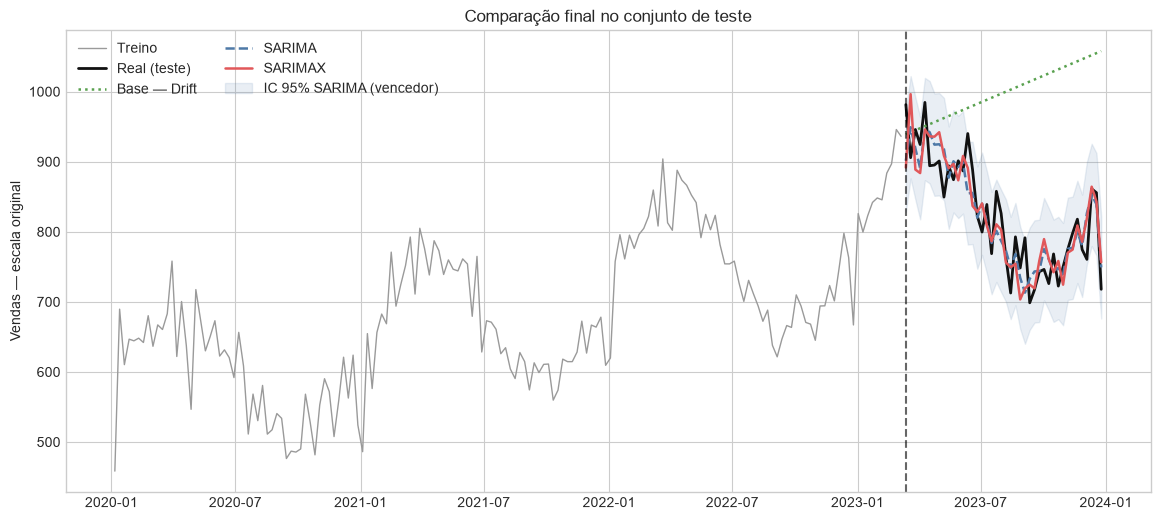

In [12]:
cor_ic = "#E15759" if vencedor_arima == "SARIMAX" else "#4E79A7"

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(treino.index, treino["vendas"], color="#9A9A9A", linewidth=1.0, label="Treino")
ax.plot(teste.index, teste["vendas"], color="#111111", linewidth=2.0, label="Real (teste)")
ax.plot(previsoes.index, previsoes[nome_base], color="#59A14F", linestyle=":", linewidth=1.8, label=nome_base)
ax.plot(previsoes.index, previsoes["SARIMA"], color="#4E79A7", linestyle="--", linewidth=1.8, label="SARIMA")
ax.plot(previsoes.index, previsoes["SARIMAX"], color="#E15759", linewidth=1.8, label="SARIMAX")
ax.fill_between(teste.index, ic_inferior, ic_superior, color=cor_ic, alpha=0.12, label=f"IC 95% {vencedor_arima} (vencedor)")
ax.axvline(teste.index.min(), color="black", linestyle="--", alpha=0.6)
ax.set_title("Comparação final no conjunto de teste")
ax.set_ylabel("Vendas — escala original")
ax.legend(ncol=2)
plt.show()

## 10. Previsões finais na escala original

In [13]:
previsoes_finais = pd.concat(
    [
        teste[["vendas"]].rename(columns={"vendas": "Real"}),
        previsoes,
        pd.DataFrame(
            {
                f"{vencedor_arima}_IC_inf_95%": ic_inferior,
                f"{vencedor_arima}_IC_sup_95%": ic_superior,
            },
            index=teste.index,
        ),
    ],
    axis=1,
)

display(previsoes_finais.round(2))

# Checagens simples da entrega.
assert previsoes_finais.index.equals(teste.index)
assert previsoes_finais.notna().all().all()
assert np.isfinite(previsoes_finais.to_numpy()).all()
print(f"{len(previsoes_finais)} semanas previstas, sem valores ausentes.")
print(f"Intervalo de 95% mostrado é do modelo vencedor no teste: {vencedor_arima}.")

,Real,Base — Drift,SARIMA,SARIMAX,SARIMA_IC_inf_95%,SARIMA_IC_sup_95%
data,,,,,,
2023-03-13,981.38,939.05,901.23,891.66,828.59,973.88
2023-03-20,905.66,941.95,949.15,996.31,876.15,1022.15
2023-03-27,945.90,944.84,918.92,888.71,845.92,991.91
2023-04-03,924.48,947.74,890.68,883.72,817.68,963.67
2023-04-10,984.55,950.63,946.54,945.88,873.54,1019.54
2023-04-17,894.16,953.53,941.99,936.13,868.99,1014.98
2023-04-24,895.20,956.42,924.27,935.62,851.28,997.27
2023-05-01,900.97,959.32,924.81,941.99,851.82,997.81
2023-05-08,849.47,962.21,918.00,908.40,845.01,991.00


42 semanas previstas, sem valores ausentes.
Intervalo de 95% mostrado é do modelo vencedor no teste: SARIMA.


## 11. Diagnóstico dos resíduos do modelo vencedor

O diagnóstico é feito no modelo com menor MAE no teste entre SARIMA e SARIMAX (`vencedor_arima`, seção 9) — não é assumido de antemão que o SARIMAX ganha.

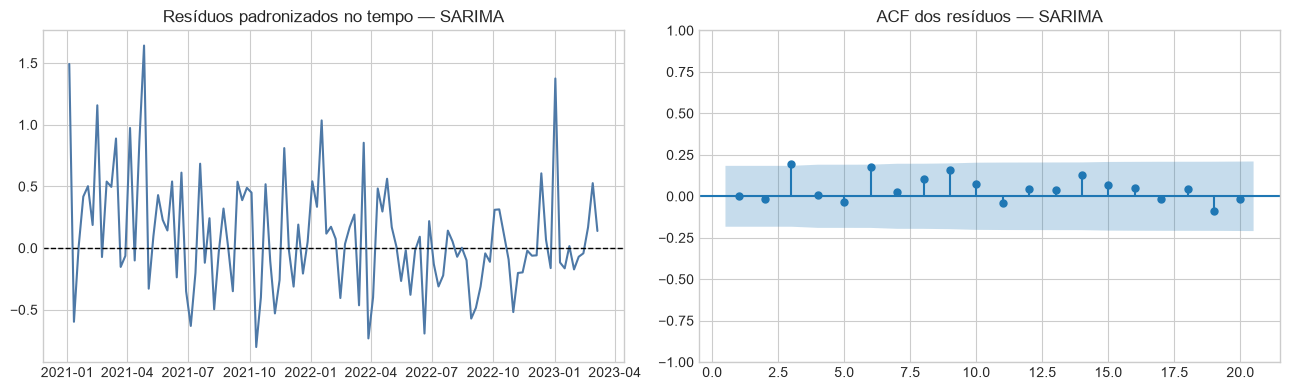

,lb_stat,lb_pvalue
10,13.9794,0.1739
20,19.2693,0.5044


Conclusão: o menor MAE no teste foi de SARIMA.
Diagnóstico de resíduos realizado no vencedor: SARIMA.
SARIMAX versus SARIMA: variação de -11.23% no MAE (positivo = SARIMAX melhor; negativo = SARIMA melhor).
Neste conjunto de teste, a grade de SARIMAX (temperatura + feriado) não superou o SARIMA puro: a ordem escolhida pela validação generalizou pior no teste do que a ordem do SARIMA. Isso é um resultado legítimo do pipeline — nem sempre as exógenas melhoram a previsão fora da amostra de validação.
As previsões apresentadas na seção 10 já estão integralmente na escala original.


In [14]:
residuos = pd.Series(modelo_vencedor.resid, index=treino.index, name="resíduo").dropna()
# Descarta a fase de inicialização sazonal do filtro para o diagnóstico visual.
residuos_diag = residuos.iloc[SAZONALIDADE:]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(residuos_diag.index, residuos_diag, color="#4E79A7")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title(f"Resíduos padronizados no tempo — {vencedor_arima}")
plot_acf(residuos_diag, lags=20, ax=axes[1], zero=False)
axes[1].set_title(f"ACF dos resíduos — {vencedor_arima}")
plt.tight_layout()
plt.show()

ljung_box = acorr_ljungbox(residuos_diag, lags=[10, 20], return_df=True)
display(ljung_box.round(4))

melhor_teste = comparacao.index[0]
mae_sarimax = comparacao.loc["SARIMAX", "MAE"]
mae_sarima = comparacao.loc["SARIMA", "MAE"]
ganho_sarimax_sobre_sarima = 100 * (mae_sarima - mae_sarimax) / mae_sarima

print(f"Conclusão: o menor MAE no teste foi de {melhor_teste}.")
print(f"Diagnóstico de resíduos realizado no vencedor: {vencedor_arima}.")
print(
    f"SARIMAX versus SARIMA: variação de {ganho_sarimax_sobre_sarima:.2f}% no MAE "
    "(positivo = SARIMAX melhor; negativo = SARIMA melhor)."
)
if vencedor_arima == "SARIMA":
    print(
        "Neste conjunto de teste, a grade de SARIMAX (temperatura + feriado) não superou o "
        "SARIMA puro: a ordem escolhida pela validação generalizou pior no teste do que a ordem "
        "do SARIMA. Isso é um resultado legítimo do pipeline — nem sempre as exógenas melhoram a "
        "previsão fora da amostra de validação."
    )
print("As previsões apresentadas na seção 10 já estão integralmente na escala original.")